## Predictive Maintenance Machine Learning Workbook - Oliver Kele

In this workbook, I'll be working with a synthetic predictive maintenance dataset from Kaggle (https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification). This dataset was created by UC Irvine to allow machine learning students to work with realistic predictive maintenance data, which is usually difficult to obtain (https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset).

This dataset has already been used widely to build machine learning models (there are 132 notebooks for this data on Kaggle), so I'll be taking a slightly different approach:

**What maintenance rules & best practices can be learnt from the data and communicated to operators?**

Here's my assumptions that lead me to pursue this research question:
* In the field, it may not always be possible to get reliable sensor data
* Operators of these machines (who are responsible for maintenance) likely do not have a machine learning background that allows them to effectively intepret complex model's outputs
* Organisations may favour simple but reliable rules that can be recorded in operator manuals and workplace health & safety documentation

I'm thinking about this problem like a pre-shift inspection. I don't need a super complicated machine learning model to tell me to check oil levels before I start a piece of machinery. However, I would like to know that if it's really cold I need to check my oil twice a day, or in certain conditions machines are prone to specific failure-modes.

This approach introduces a unique challenge: **I'm not just minimising loss, I'm also maximising explanability**.


## TL;DR

Most predictive maintenance notebooks on this dataset try to build the most accurate possible failure classifier. I'm doing something different — I want to know **what the data can teach us about how to prevent failures in the first place**.

The goal is rules an operator can actually use: *replace the tool head before X minutes*, *don't run the machine above Y watts*. No ML background required, nothing that can't be written into a manual.

Here's the approach in brief:

1. **EDA** — understand the dataset, engineer two new features (mechanical power and temperature differential), and look for relationships between operating conditions and specific failure types.
2. **Logistic GLMs** — train one binary model per failure type. GLMs give interpretable coefficients and p-values, so I can say with statistical confidence which features predict which failures — and in which direction.
3. **Threshold rules** — use the GLM-confirmed predictors to find the operating point where failure rate crosses 1%. That becomes the maintenance rule threshold.
4. **'Is it worth it?' analysis** — for each rule, show the trade-off between failures caught and healthy machines unnecessarily flagged.

**Key findings:**
- Tool wear predicts two failure types almost perfectly. A scheduled replacement rule catches the vast majority of both.
- High mechanical power is a significant risk factor for heat dissipation and overstrain failures.
- Temperature differential is a monitoring signal for cooling system health.
- Power failures cannot be reliably predicted from operational data — no rule is proposed for them.


## A Note on AI Use

I used an AI coding assistant (OpenCode - Claude Sonnet 4.6) to help write and debug code throughout this notebook.

I did all the thinking, Claude did most of the writing.

Any engineering decisions - from the research question to choice of models & parameters - and interpretations are mine. That's not to say Claude didn't write a bunch of code or draft discussion points, but I retained control. This notebook is not what you would get giving AI a csv and free reign.

The thing I like most about AI is it frees me up to thinking more about these engineering decisions. As an example, I had never used SMOTES before this project. Instead of reading documentation on how to implement them, I spent my time understanding how they work and would help my models.

**The other thing I love about AI is I got to put together this cool analysis in one (1!!) day.**


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.display import Markdown, display
def printmd(string):
    display(Markdown(string))

## Exploratory Data Analysis

Before I get stuck into some exploratory analysis, here's an overview of my data from Kaggle:

""" The dataset consists of 10 000 data points stored as rows with 14 features in columns

* UID: unique identifier ranging from 1 to 10000
* productID: consisting of a letter L, M, or H for low (50% of all products), medium (30%), and high (20%) as product quality variants and a variant-specific serial number
* air temperature [K]: generated using a random walk process later normalized to a standard deviation of 2 K around 300 K
* process temperature [K]: generated using a random walk process normalized to a standard deviation of 1 K, added to the air temperature plus 10 K.
* rotational speed [rpm]: calculated from powepower of 2860 W, overlaid with a normally distributed noise
* torque [Nm]: torque values are normally distributed around 40 Nm with an Ïƒ = 10 Nm and no negative values.
* tool wear [min]: The quality variants H/M/L add 5/3/2 minutes of tool wear to the used tool in the process. and a
* 'machine failure' label that indicates, whether the machine has failed in this particular data point for any of the following failure modes are true.

Important : There are two Targets - Do not make the mistake of using one of them as feature, as it will lead to leakage.

* Target : Failure or Not
* Failure Type : Type of Failure """


In [33]:
df = pd.read_csv('predictive_maintenance.csv')
df.head()

# Checking data for null values and duplicate product ID's
n = df.shape[0]
print('Features non-null values and data type: \n')
df.info()
print('\nCheck for duplicate values: \n', 
      df['Product ID'].unique().shape[0]!=n)

Features non-null values and data type: 

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  str    
dtypes: float64(3), int64(4), str(3)
memory usage: 950.2 KB

Check for duplicate values: 
 False


The data has non null values or duplicate product ID's. This is expected as the data is synthetic. Looking at the columns, there is a unique id (UDI) and another unique identifier column, Product ID. Before going any further, I'll look at Product ID to see if there is any additional information encoded in it, then I'll choose one unique identifier column to use moving forward.

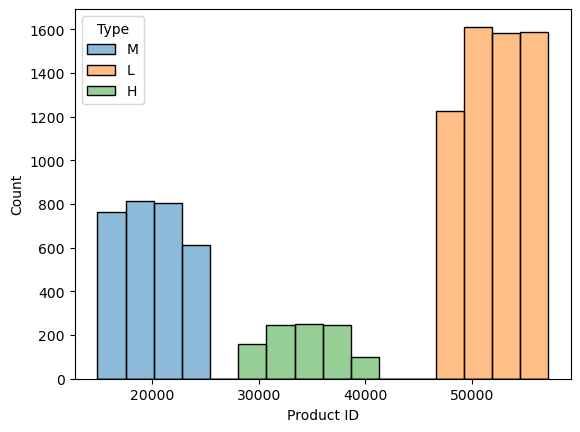

In [34]:
# Remove first character and set to numeric dtype
df['Product ID'] = df['Product ID'].apply(lambda x: x[1:])
df['Product ID'] = pd.to_numeric(df['Product ID'])

# Histogram of ProductID
sns.histplot(data=df, x='Product ID', hue='Type')
plt.show()

# This code snippet (only) was borrowed from a Kaggle notebook: https://www.kaggle.com/code/gerardocappa/predictive-maintenance-final-project#Introduction

Product ID does not seem to have any additional information encoded (the number just relates to type), so I'll use UDI as my unique identifier moving forward.

I now want to understand the distribution of Failure Types in the dataset, before investigating the relationship between different features and failure.

In [35]:
# Dropping Product ID from my dataframe as it does not seem to have any information of interest encoded

df.drop(columns=['Product ID'])

# Visualising the distribution of failure types

counts = df['Failure Type'].value_counts()
percentages = df['Failure Type'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'Count': counts,
    'Percentage': percentages
})

print(summary)

                          Count  Percentage
Failure Type                               
No Failure                 9652       96.52
Heat Dissipation Failure    112        1.12
Power Failure                95        0.95
Overstrain Failure           78        0.78
Tool Wear Failure            45        0.45
Random Failures              18        0.18


Obviously theres some very unbalanced classes here that will needed to be considered later on. 

I'll now look at features relationships with failure to see if there are any general relationships that apply to all failure types. Then I'll do some more exploratory data analysis looking at each failure type individually.

<h3><center> Features vs Failure (0 = No Failure, 1 = Failure)</center></h3>

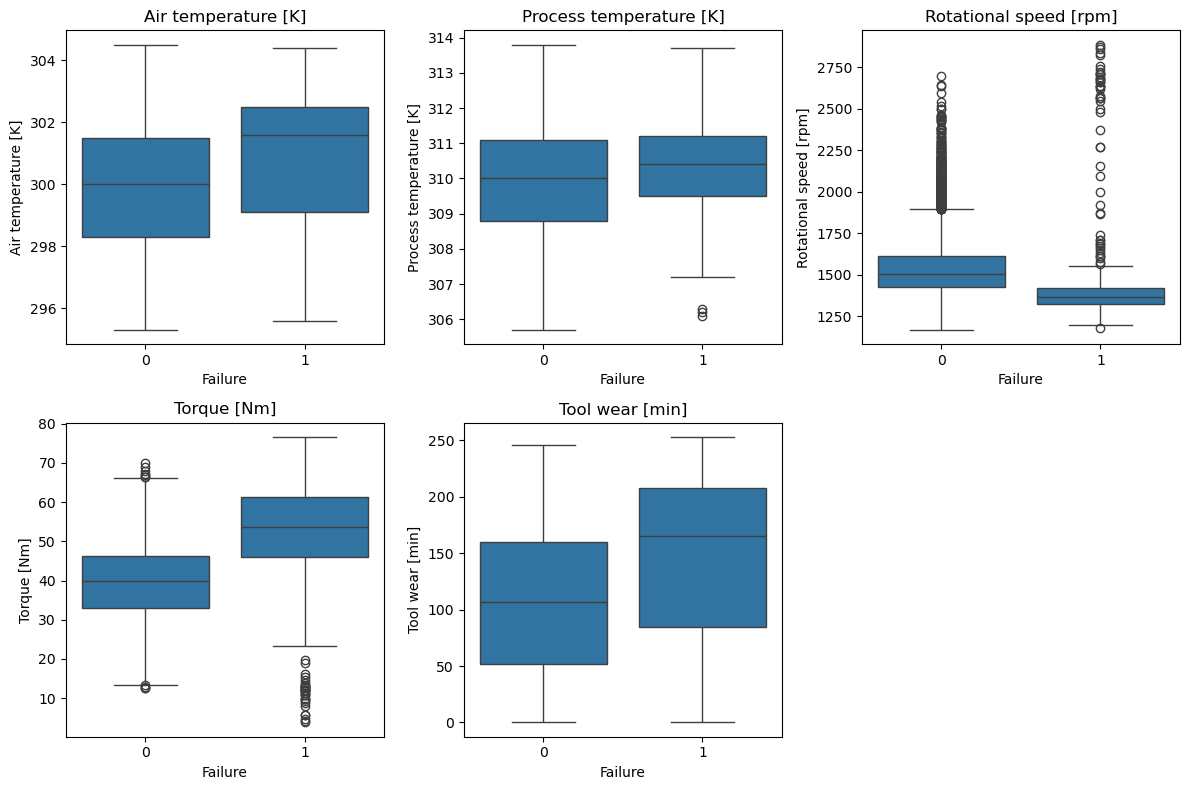

In [36]:
printmd("<h3><center> Features vs Failure (0 = No Failure, 1 = Failure)</center></h3>")

features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df, x="Target", y=feature, ax=axes[i])
    
    axes[i].set_title(feature)
    axes[i].set_xlabel("Failure")
    axes[i].set_ylabel(feature)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

These boxplots appear to show some relationships between features and machine failure. For example, it appears that machines with lower rotational speed fail more often as do machines with higher torque. I'll now take a look at how these features relationship with machine failure differs by tool quality (H/M/L).

<h3><center> Features vs Failure (0 = No Failure, 1 = Failure), Seperated by Tool Quality</center></h3>

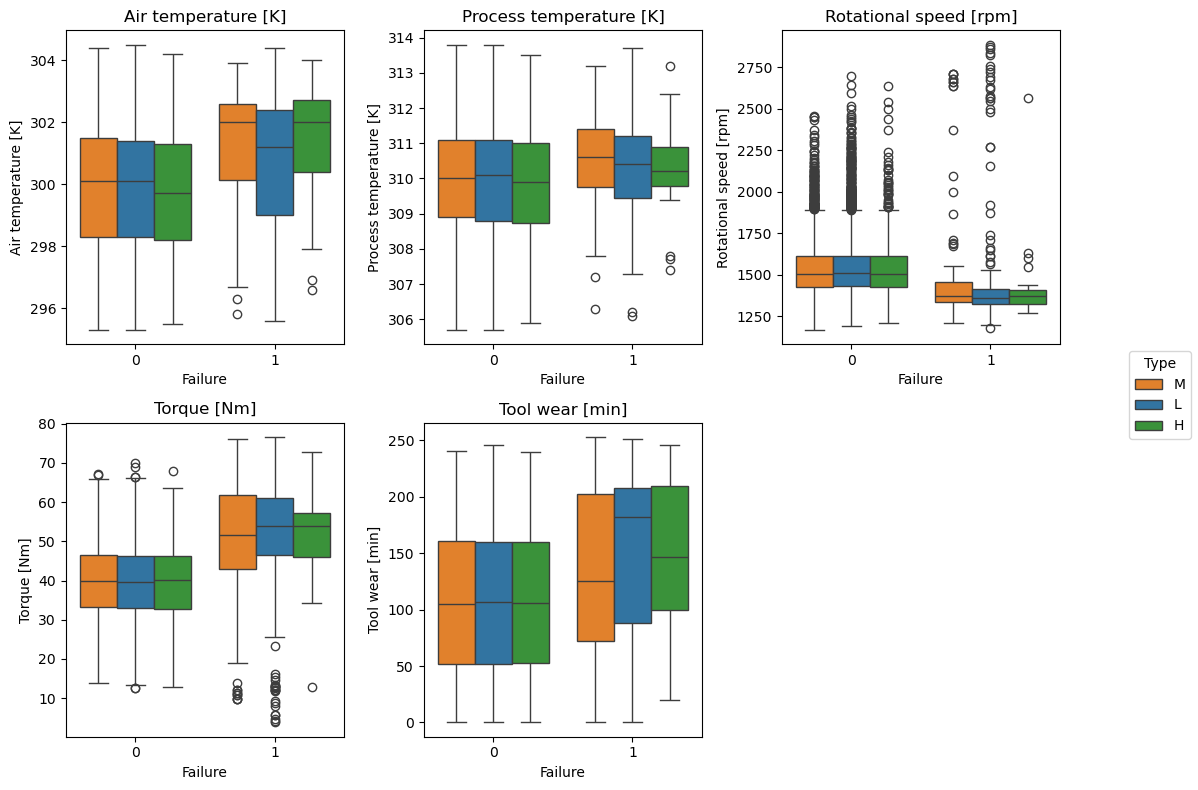

In [37]:
printmd("<h3><center> Features vs Failure (0 = No Failure, 1 = Failure), Seperated by Tool Quality</center></h3>")

palette = {"L": "#1f77b4", "M": "#ff7f0e", "H": "#2ca02c"}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=df,
        x="Target",
        y=feature,
        hue="Type",
        palette=palette,
        ax=axes[i]
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("Failure")
    axes[i].set_ylabel(feature)
    axes[i].legend_.remove()

axes[-1].remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Type", loc="center right")

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

It doens't look like seperating the data by tool quality type (H/M/L) made a significant difference to the relationships between features and failure. Before I go any further, I'd like to take a look at two new calculated features:

1. Power - calculated from Torque and Rotational Speed (rpm).
2. Temperature Difference - calculated by subtracting the air temperature from the process temperature.

My hypothesis is these two features have information about the machines performance, and therefore might have a relationship with failure.

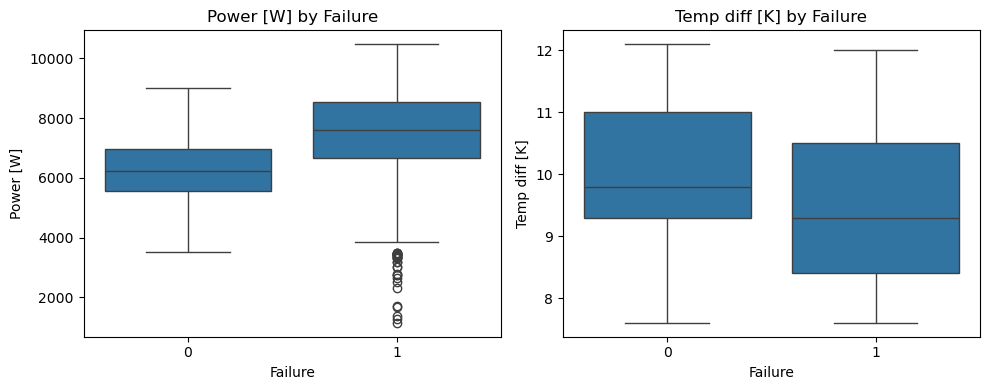

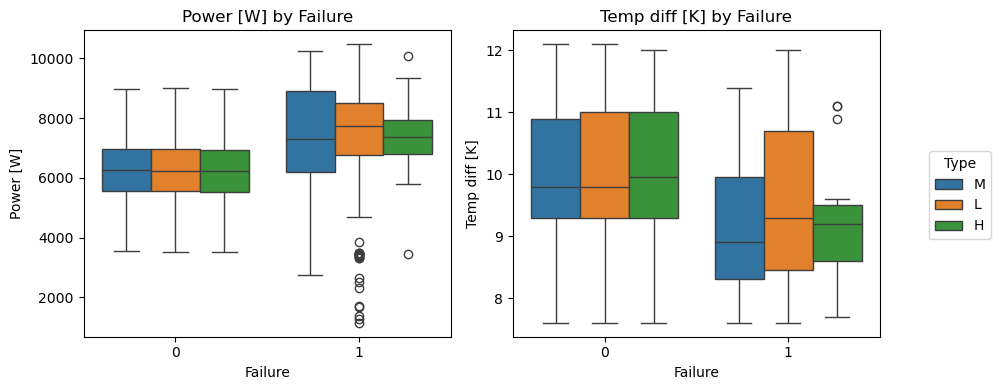

In [38]:
# Calculating New Features

df["Power [W]"] = df["Torque [Nm]"] * (np.pi * df["Rotational speed [rpm]"] / 30)

df["Temp diff [K]"] = df["Process temperature [K]"] - df["Air temperature [K]"]

# Boxplots vs Failure

features_new = ["Power [W]", "Temp diff [K]"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, feature in enumerate(features_new):
    sns.boxplot(data=df, x="Target", y=feature, ax=axes[i])
    axes[i].set_title(f"{feature} by Failure")
    axes[i].set_xlabel("Failure")
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()


# Boxplots seperated by tool quality

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, feature in enumerate(features_new):
    sns.boxplot(
        data=df,
        x="Target",
        y=feature,
        hue="Type",
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} by Failure")
    axes[i].set_xlabel("Failure")
    axes[i].set_ylabel(feature)
    axes[i].legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Type", loc="center right")

plt.tight_layout(rect=[0,0,0.9,1])
plt.show()

This appears to show a relationship between power and failure - higher power machines fail more often. This is consistent across tool qualities. In contrast, there does not seem to be a strong relationship between temperature difference and failure.

I'll now reproduce these boxplots looking at each failure type individually.

<h3><center>Features vs Failure (0 = No Failure, 1 = Failure) by Failure Type </center></h3>

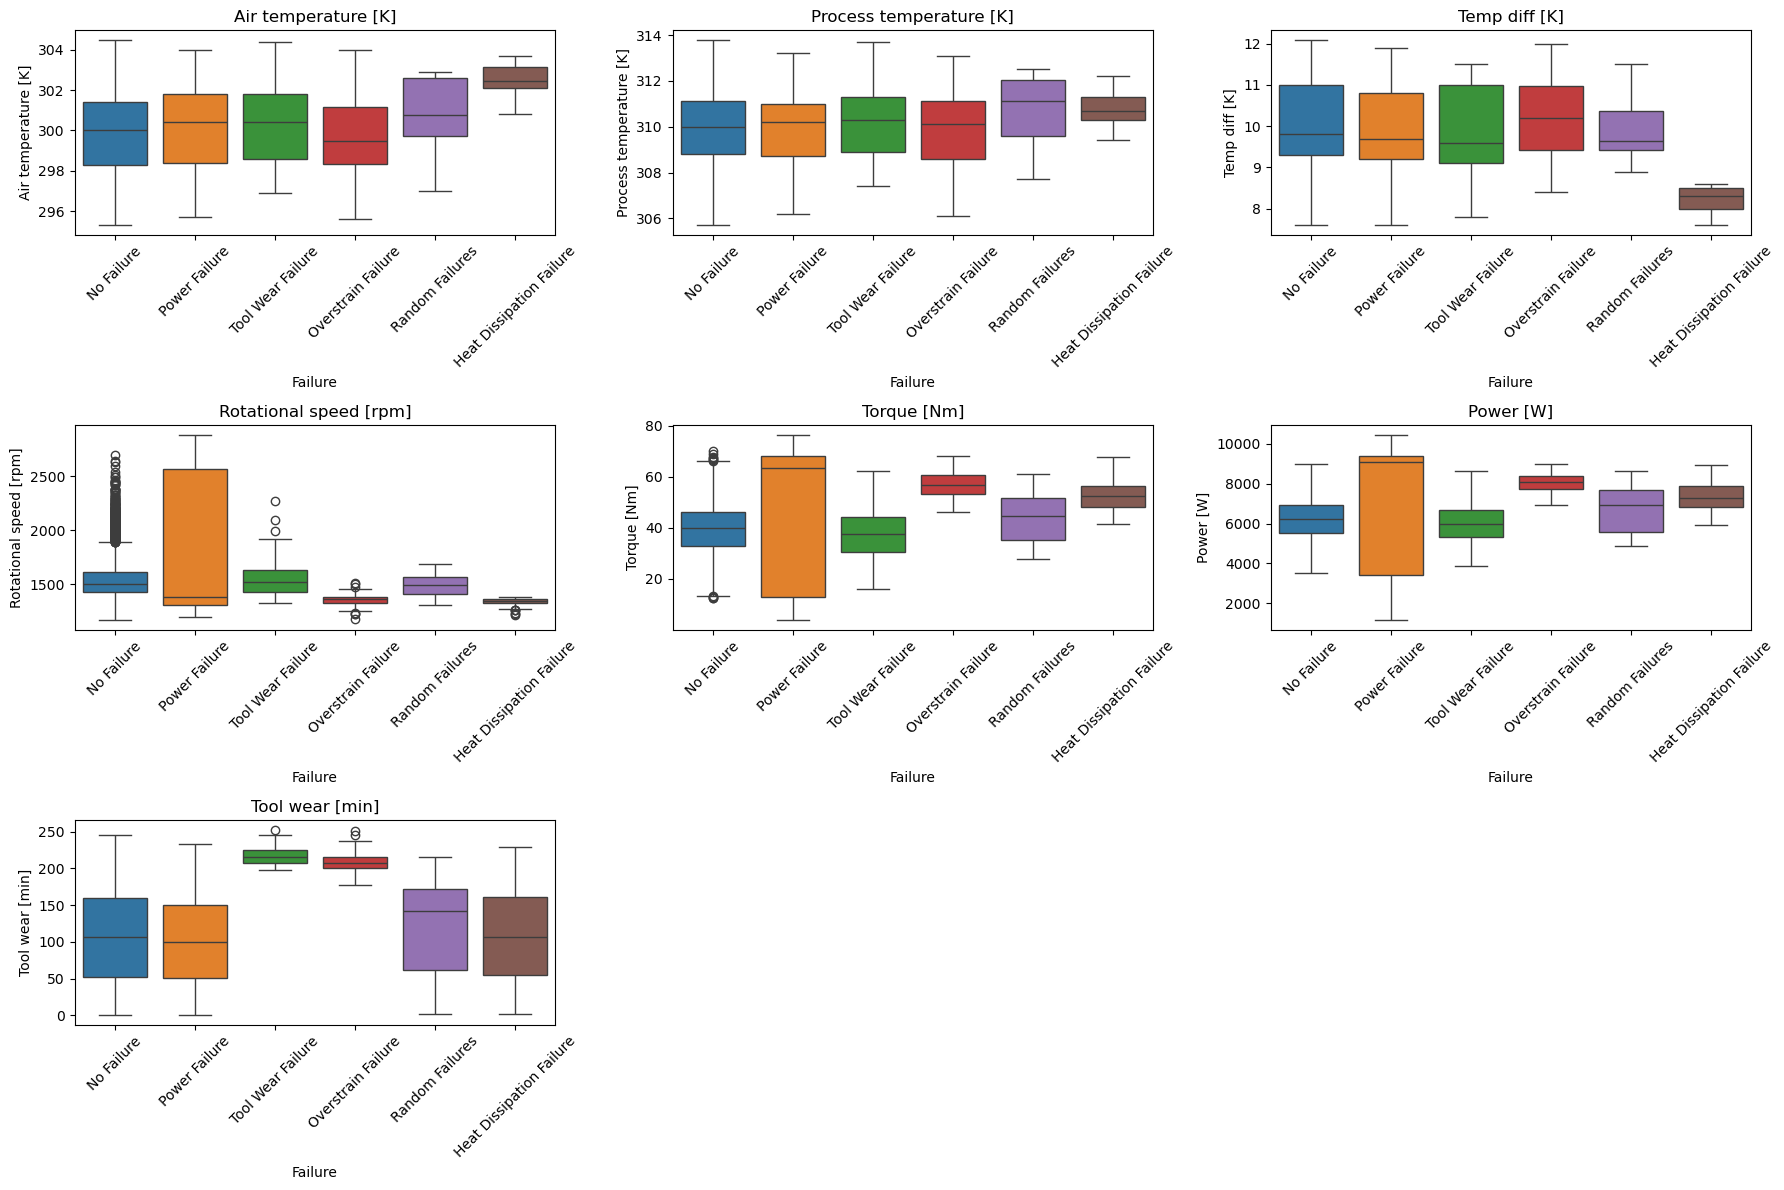

In [39]:
printmd("<h3><center>Features vs Failure (0 = No Failure, 1 = Failure) by Failure Type </center></h3>")

features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Temp diff [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Power [W]",
    "Tool wear [min]"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=df,
        x="Failure Type", 
        y=feature, 
        hue="Failure Type",  # separates by failure type
        ax=axes[i]
    )
    
    axes[i].set_title(feature)
    axes[i].set_xlabel("Failure")
    axes[i].set_ylabel(feature)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Looking at these boxplots, I'm starting to see some strong relationships between some features and specific failure types. For example, tool wear failures and overstrain failures have a very strong relationship with tool wear. I've also noticed that the new features I calculated (power and temp diff) seem to have strong relationships with some types of tool failures.

This leads me to the following hypothesis:

As I'm optimising for explanability, **the best approach might be to train multiple models that each predict one type of failure**. I could also look at grouping similair failure types into one model - tool wear failure and overstrain failure may be good candidates for this.

By training models for specific types of failure, hopefully I'll be able to develop different mainteance rules & best practices that can be applied to prevent these failures. 

## Linear Regression - Using Logistic GLMs

**Why am I starting with logistic GLMs?**

* I want explainability - GLMs give me interpretable coefficients. For example, if I learn that temperature difference has a statistically significant positive impact on machine failures, that's actionable! I can inform operators that reducing temperature difference can help prevent failures.
* GLMs produce standard errors, p-values, and other statistical metrics I can use to weigh advice. For example, I might find with high confidence that high tool wear increase the likelihood of failures. Again, this means I can communicate to operators the importance of replacing tools before X hours of operation.

**TL;DR GLMs have high explanability, which is something I care about.**

Before I can start training GLMs, I have to do something about the class imbalances.

I'm going to try two approaches:

1. SMOTE (Synthetic Minority Oversampling Technique): For each minority sample (i.e. failure types), I pick a few nearest neighbours (from the same minority class) and generate new points along the line connecting them.
2. Class Weights: Weighting misclassifications of minority classes, so the model 'pays more attention' to the failure types.

For now, I'm going to ignore H/M/L tool quality as modelling this categorical variable adds complexity I'm not sure I'll need. I'll might come back to this feature later depending on how my models perform.

As my sample size for failures is already small, I won't use a validation set. Instead I'll use a 80/20 training/test split. For reproducability, I'll also set a random seed.

In [40]:
# --- Cell 1: GLM Imports ---
%pip install imbalanced-learn
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.


### Feature Preparation

Before fitting the GLMs I need to decide which features to include. The EDA showed that Torque and RPM are both related to failure, but they're not independent — power is just torque times angular velocity. Using both raw features in the same model would introduce multicollinearity, so I'll use the engineered `Power [W]` feature instead and drop the originals. Same logic applies to `Process temp` and `Air temp` — the temperature differential captures what actually matters (how well the machine is dissipating heat).

That leaves three predictors for each GLM:

| Feature | Rationale |
|---|---|
| `Power [W]` | Torque × angular velocity — captures mechanical load without redundant raw features |
| `Temp diff [K]` | Process temp − Air temp — captures cooling performance |
| `Tool wear [min]` | Retained as-is |

All three are **z-scored** before fitting. This doesn't change the relationships, but it means the coefficients are on the same scale, so I can compare them directly across features.

In [41]:
# --- Cell 2: Feature prep & scaling ---

# Engineered features should already exist from earlier cells.
# Recreate them here in case this cell is run independently.
if 'Power [W]' not in df.columns:
    df['Power [W]'] = df['Torque [Nm]'] * (np.pi * df['Rotational speed [rpm]'] / 30)
if 'Temp diff [K]' not in df.columns:
    df['Temp diff [K]'] = df['Process temperature [K]'] - df['Air temperature [K]']

FEATURES = ['Power [W]', 'Temp diff [K]', 'Tool wear [min]']
RANDOM_STATE = 42

# Fit scaler on the full dataset (scaling parameters; not a data-leakage concern
# because we are only scaling X, not using the target in any way).
scaler = StandardScaler()
scaler.fit(df[FEATURES])

print('Scaler fitted on features:', FEATURES)
print('Means :', dict(zip(FEATURES, scaler.mean_.round(4))))
print('Std   :', dict(zip(FEATURES, scaler.scale_.round(4))))

Scaler fitted on features: ['Power [W]', 'Temp diff [K]', 'Tool wear [min]']
Means : {'Power [W]': np.float64(6279.745), 'Temp diff [K]': np.float64(10.0006), 'Tool wear [min]': np.float64(107.951)}
Std   : {'Power [W]': np.float64(1067.3649), 'Temp diff [K]': np.float64(1.001), 'Tool wear [min]': np.float64(63.651)}


### GLM Helper Function

The function below fits a **binary logistic GLM** for a single failure type against the No Failure baseline. A few design decisions worth explaining:

**Why drop rows with other failure types?** Each GLM is asking a specific question: *given that a machine either ran fine or had a Heat Dissipation Failure, what conditions predicted that?* Including rows from other failure types would contaminate the negative class — an Overstrain Failure row isn't a clean 'no failure' example. Dropping them keeps the binary signal clean and the coefficients interpretable.

**Two imbalance strategies — why both?** Failure classes are heavily imbalanced (as low as 0.45% of the data). If both strategies produce similar coefficients and p-values, that's a good sign the relationships are real and not an artefact of how the imbalance was handled.
- `'smote'` — synthetic minority samples are generated in feature space on the **training set only**.
- `'freq_weights'` — minority training rows are upweighted by `n_majority / n_minority`. No new data is created, just different influence in the likelihood.

Both are evaluated on the **same held-out 20% test set** (stratified split) so the comparison is fair.

In [42]:
# --- Cell 3: Helper function ---

def fit_glm(failure_type, method='smote', random_state=RANDOM_STATE):
    """
    Fit a binary logistic GLM for one failure type vs No Failure.

    Parameters
    ----------
    failure_type : str
        One of the failure type labels in df['Failure Type'].
    method : {'smote', 'freq_weights'}
        Class-imbalance handling strategy.
    random_state : int
        Seed for reproducibility.
    """
    divider = '=' * 72
    print(f'\n{divider}')
    print(f'  Failure type : {failure_type}')
    print(f'  Method       : {method}')
    print(divider)

    # ------------------------------------------------------------------
    # 1. Filter to binary problem: target failure type vs No Failure
    # ------------------------------------------------------------------
    mask = df['Failure Type'].isin(['No Failure', failure_type])
    df_binary = df[mask].copy()
    df_binary['target'] = (df_binary['Failure Type'] == failure_type).astype(int)

    n_pos = df_binary['target'].sum()
    n_neg = len(df_binary) - n_pos
    print(f'  Class counts after filtering  ->  No Failure: {n_neg}  |  {failure_type}: {n_pos}')

    # ------------------------------------------------------------------
    # 2. Scale features (use the scaler fitted on the full dataset)
    # ------------------------------------------------------------------
    X = pd.DataFrame(
        scaler.transform(df_binary[FEATURES]),
        columns=FEATURES,
        index=df_binary.index
    )
    y = df_binary['target']

    # ------------------------------------------------------------------
    # 3. Stratified 80/20 train/test split
    # ------------------------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )
    print(f'  Train size: {len(X_train)}  |  Test size: {len(X_test)}')

    # ------------------------------------------------------------------
    # 4a. SMOTE: oversample minority class in training set only
    # ------------------------------------------------------------------
    if method == 'smote':
        smote = SMOTE(random_state=random_state)
        X_train_fit, y_train_fit = smote.fit_resample(X_train, y_train)
        X_train_fit = pd.DataFrame(X_train_fit, columns=FEATURES)
        y_train_fit = pd.Series(y_train_fit, name='target')
        freq_weights = None
        print(f'  After SMOTE  ->  class 0: {(y_train_fit==0).sum()}  |  class 1: {(y_train_fit==1).sum()}')

    # ------------------------------------------------------------------
    # 4b. Frequency weights: upweight minority rows (no new rows)
    # ------------------------------------------------------------------
    elif method == 'freq_weights':
        X_train_fit = X_train.copy()
        y_train_fit = y_train.copy()
        n_maj = (y_train == 0).sum()
        n_min = (y_train == 1).sum()
        weight_minority = n_maj / n_min  # balance ratio
        freq_weights = y_train_fit.map({0: 1.0, 1: weight_minority})
        print(f'  Minority weight: {weight_minority:.2f}  (n_maj={n_maj}, n_min={n_min})')
        print('  Note: statsmodels inflates Df Residuals by the total weight sum, not row count.')
        print('        This is expected — it does not affect coefficients or p-values.')

    else:
        raise ValueError(f"method must be 'smote' or 'freq_weights', got '{method}'")

    # ------------------------------------------------------------------
    # 5. Add intercept column and fit statsmodels GLM
    # ------------------------------------------------------------------
    X_train_sm = sm.add_constant(X_train_fit, has_constant='add')

    glm_kwargs = dict(
        endog=y_train_fit,
        exog=X_train_sm,
        family=sm.families.Binomial()
    )
    if freq_weights is not None:
        glm_kwargs['freq_weights'] = freq_weights.values

    model = sm.GLM(**glm_kwargs)
    result = model.fit()

    print('\n--- statsmodels GLM Summary ---')
    print(result.summary())

    # Odds ratios with 95 % CIs (exponentiated coefficients)
    coef_df = pd.DataFrame({
        'coef'      : result.params.round(4),
        'odds_ratio': np.exp(result.params).round(4),
        'CI_lower'  : np.exp(result.conf_int()[0]).round(4),
        'CI_upper'  : np.exp(result.conf_int()[1]).round(4),
        'p_value'   : result.pvalues  # kept as float; formatted below
    })
    # Format p-values in scientific notation so tiny values don't display as 0.0
    coef_df['p_value'] = coef_df['p_value'].map(lambda p: f'{p:.3e}')
    print('\n--- Odds Ratios & 95% Confidence Intervals ---')
    print(coef_df.to_string())

    # ------------------------------------------------------------------
    # 6. Evaluate on the held-out test set
    # ------------------------------------------------------------------
    X_test_sm = sm.add_constant(X_test, has_constant='add')
    y_pred_proba = result.predict(X_test_sm)
    y_pred = (y_pred_proba >= 0.5).astype(int)

    print('\n--- Test Set Evaluation ---')
    print(classification_report(y_test, y_pred, target_names=['No Failure', failure_type]))

    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=['Actual: No Failure', f'Actual: {failure_type}'],
        columns=['Predicted: No Failure', f'Predicted: {failure_type}']
    )
    print('Confusion Matrix:')
    print(cm_df.to_string())

    try:
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f'\nROC-AUC: {auc:.4f}')
    except ValueError:
        print('\nROC-AUC: could not be computed (only one class in test set)')

    print(f'\n{divider}\n')

    # Return everything needed for visualisations
    return {
        'result'      : result,
        'coef_df'     : coef_df,
        'y_test'      : y_test,
        'y_pred'      : y_pred,
        'y_pred_proba': y_pred_proba,
        'failure_type': failure_type,
        'method'      : method,
    }

### Run GLMs — 4 Failure Types × 2 Imbalance Methods

Running 8 models in total — each failure type under both imbalance strategies. This is going to produce a lot of output, but the key things to look for are:
- Do SMOTE and frequency weights agree on which features are significant?
- Are the coefficient directions what the EDA suggested?
- Is the AUC high enough that these features are actually useful predictors?

If the two strategies broadly agree, that's confidence the relationships are real. If they disagree, the signal is probably too weak to act on.

#### NOTE -- THERES A LOT OF TEXT, SKIP AHEAD TO THE VISUALISATIONS IF YOU WANT :)

In [43]:
# --- Cell 4: Run all 4 models x 2 methods ---

FAILURE_TYPES = [
    'Heat Dissipation Failure',
    'Power Failure',
    'Overstrain Failure',
    'Tool Wear Failure',
]

METHODS = ['smote', 'freq_weights']

results = {}
for ft in FAILURE_TYPES:
    for method in METHODS:
        results[(ft, method)] = fit_glm(ft, method=method)

print('\nAll models fitted. Stored in results[(failure_type, method)].')


  Failure type : Heat Dissipation Failure
  Method       : smote
  Class counts after filtering  ->  No Failure: 9652  |  Heat Dissipation Failure: 112
  Train size: 7811  |  Test size: 1953
  After SMOTE  ->  class 0: 7721  |  class 1: 7721

--- statsmodels GLM Summary ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 target   No. Observations:                15442
Model:                            GLM   Df Residuals:                    15438
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1949.6
Date:                Sun, 15 Mar 2026   Deviance:                       3899.2
Time:                        08:02:01   Pearson chi2:                 7.59e+04
No. Iterations:                     9   Pseudo R-squ. (CS):             0.6782
Covariance Ty

## Interpreting the GLM Output

There's a lot of output from the models above — here's what to focus on.

### The statsmodels summary

| Column | What it means |
|---|---|
| `coef` | Log-odds coefficient. Positive = feature increases failure risk, negative = decreases it. |
| `std err` | Standard error of the estimate. Smaller = more confident. |
| `z` | z-statistic (`coef / std err`). Beyond ±1.96 = significant at 5%. |
| `P>\|z\|` | p-value. Below 0.05 = the feature is a statistically significant predictor of this failure type. |
| `[0.025  0.975]` | 95% confidence interval. If it doesn't cross zero, the effect is real. |

### Odds ratios — the number I actually care about

This is the GLM output I'll use to answer my research question. An odds ratio tells me: *for a one-standard-deviation increase in this feature, how much does the odds of this failure type multiply?*

- **OR > 1** — higher values of this feature mean more failures. *Example: OR = 12 for Power [W] in Heat Dissipation → machines running 1 SD above average power have 12× higher odds of overheating.*
- **OR < 1** — higher values mean fewer failures. This is a protective feature.
- **OR ≈ 1** — this feature doesn't move the needle for this failure type.

Large ORs on statistically significant features are the direct answer to my research question — they tell me which operating conditions predict which failures, and that's what I'll turn into maintenance rules in the next section.

### Do SMOTE and frequency weights agree?

If both imbalance strategies give similar coefficients and p-values, the relationships are robust — the signal isn't an artefact of how I handled the class imbalance. If they disagree significantly, I should be cautious about acting on that result.

## GLM Visualisations

The output above has a lot of numbers. These four plots are an easier way to read the same results.

1. **Forest plot** — log-odds coefficient ± 95% CI for every predictor in every model. Bars that don't cross zero are significant. Longer bars = larger effect.
2. **Odds ratio heatmap** — at a glance, which features drive which failure types? Red = increases risk, blue = decreases risk, darker = stronger association.
3. **ROC curves** — how well does each model actually discriminate on the held-out test set? AUC close to 1.0 = useful predictor, AUC close to 0.5 = no better than a coin flip.
4. **Confusion matrices** — for each model: how many actual failures did it catch, and how many healthy machines did it flag unnecessarily?

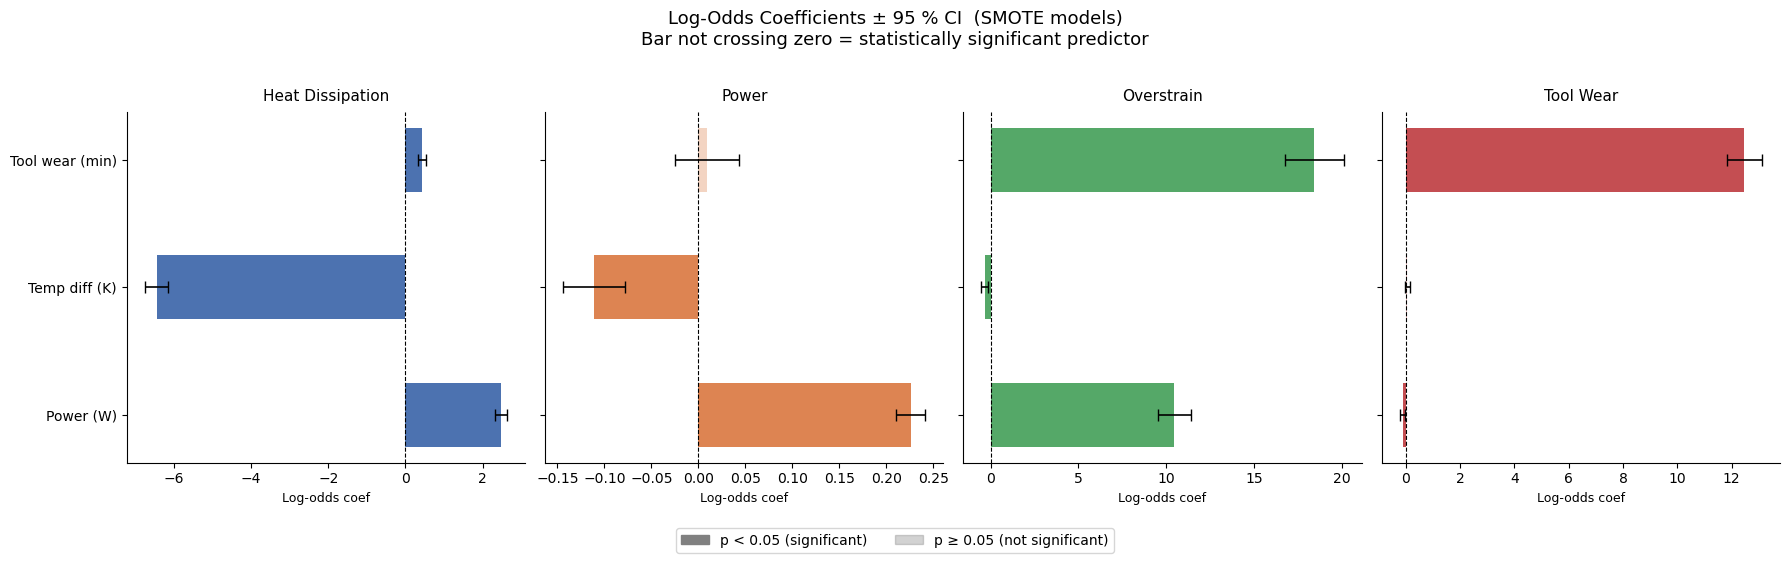

In [44]:
from sklearn.metrics import roc_curve
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

# Short labels for plots
FAILURE_LABELS = {
    'Heat Dissipation Failure': 'Heat Dissipation',
    'Power Failure'           : 'Power',
    'Overstrain Failure'      : 'Overstrain',
    'Tool Wear Failure'       : 'Tool Wear',
}
FEATURE_LABELS = {
    'Power [W]'      : 'Power (W)',
    'Temp diff [K]'  : 'Temp diff (K)',
    'Tool wear [min]': 'Tool wear (min)',
}

# ── colour palette ──────────────────────────────────────────────────────────
MODEL_COLOURS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
SMOTE_COLOUR  = '#4C72B0'
FW_COLOUR     = '#DD8452'

# ============================================================
# Plot 1: Forest plot — coefficients ± 95 % CI (SMOTE models)
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
fig.suptitle(
    'Log-Odds Coefficients ± 95 % CI  (SMOTE models)\n'
    'Bar not crossing zero = statistically significant predictor',
    fontsize=13, y=1.02
)

for ax, (ft, colour) in zip(axes, zip(FAILURE_TYPES, MODEL_COLOURS)):
    res = results[(ft, 'smote')]['result']
    # exclude intercept
    params = res.params.drop('const')
    ci     = res.conf_int().drop('const')
    pvals  = res.pvalues.drop('const')

    feat_names = [FEATURE_LABELS[f] for f in params.index]
    y_pos = range(len(params))

    for i, (feat, coef, (lo, hi), pv) in enumerate(
            zip(feat_names, params, ci.values, pvals)):
        sig   = pv < 0.05
        alpha = 1.0 if sig else 0.35
        ax.barh(i, coef, xerr=[[coef - lo], [hi - coef]],
                color=colour, alpha=alpha, height=0.5,
                error_kw=dict(ecolor='black', capsize=4, lw=1.2))

    ax.axvline(0, color='black', lw=0.8, linestyle='--')
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(feat_names, fontsize=10)
    ax.set_title(FAILURE_LABELS[ft], fontsize=11, pad=8)
    ax.set_xlabel('Log-odds coef', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

sig_patch   = mpatches.Patch(color='grey', alpha=1.0,  label='p < 0.05 (significant)')
insig_patch = mpatches.Patch(color='grey', alpha=0.35, label='p ≥ 0.05 (not significant)')
fig.legend(handles=[sig_patch, insig_patch], loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.08), fontsize=10)
plt.tight_layout()
plt.show()

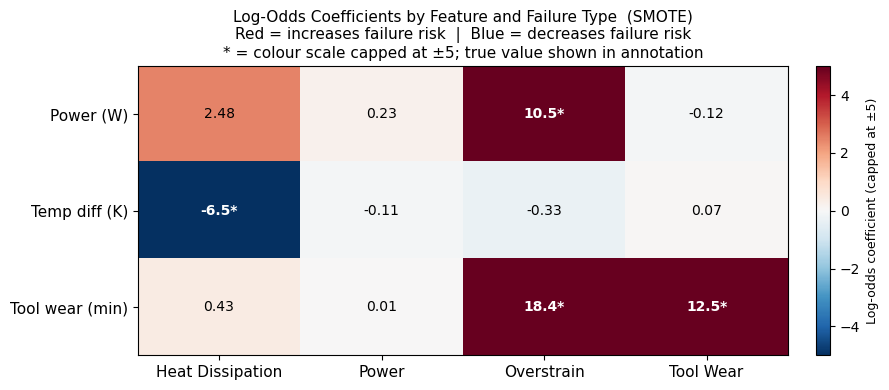

In [45]:
# ============================================================
# Plot 2: Odds-ratio heatmap  (SMOTE models, predictors only)
# Note: Overstrain & Tool Wear have astronomically large ORs
# for Tool wear [min] due to near-perfect separation — we
# cap the colour scale at ±5 log-odds so other models remain
# readable, and annotate the capped cells.
# ============================================================

ft_short   = [FAILURE_LABELS[ft] for ft in FAILURE_TYPES]
feat_short = [FEATURE_LABELS[f]  for f in FEATURES]

# Build matrix of log-odds coefficients (rows = features, cols = failure types)
coef_matrix = np.zeros((len(FEATURES), len(FAILURE_TYPES)))
for j, ft in enumerate(FAILURE_TYPES):
    res = results[(ft, 'smote')]['result']
    for i, feat in enumerate(FEATURES):
        coef_matrix[i, j] = res.params[feat]

CAP = 5.0   # cap for colour scale
coef_capped = np.clip(coef_matrix, -CAP, CAP)

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(coef_capped, cmap='RdBu_r', aspect='auto',
               vmin=-CAP, vmax=CAP)

ax.set_xticks(range(len(FAILURE_TYPES)))
ax.set_xticklabels(ft_short, fontsize=11)
ax.set_yticks(range(len(FEATURES)))
ax.set_yticklabels(feat_short, fontsize=11)
ax.set_title(
    'Log-Odds Coefficients by Feature and Failure Type  (SMOTE)\n'
    'Red = increases failure risk  |  Blue = decreases failure risk\n'
    '* = colour scale capped at ±5; true value shown in annotation',
    fontsize=11
)

for i in range(len(FEATURES)):
    for j in range(len(FAILURE_TYPES)):
        val    = coef_matrix[i, j]
        capped = abs(val) > CAP
        label  = f'{val:.1f}*' if capped else f'{val:.2f}'
        # pick contrasting text colour
        normed = (coef_capped[i, j] + CAP) / (2 * CAP)
        txt_col = 'white' if (normed < 0.25 or normed > 0.75) else 'black'
        ax.text(j, i, label, ha='center', va='center',
                fontsize=10, color=txt_col, fontweight='bold' if capped else 'normal')

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('Log-odds coefficient (capped at ±5)', fontsize=9)
plt.tight_layout()
plt.show()

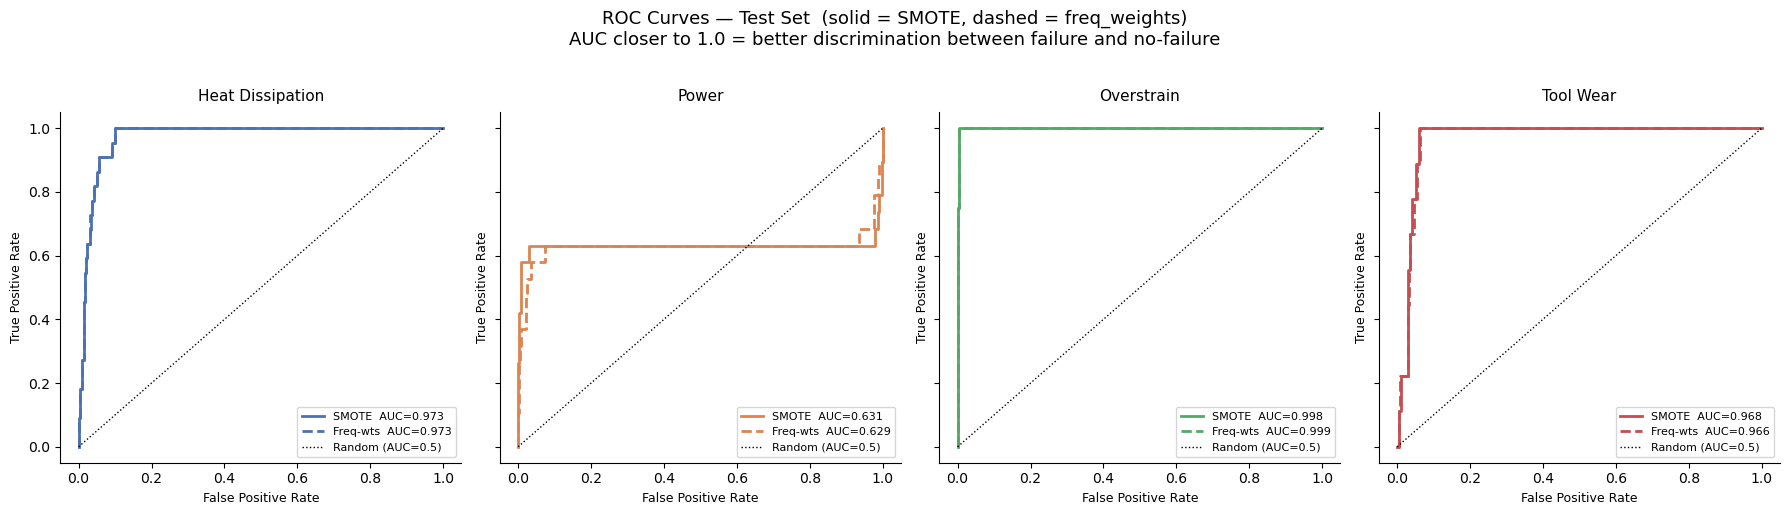

In [46]:
# ============================================================
# Plot 3: ROC curves — all 4 models, SMOTE vs freq_weights
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
fig.suptitle(
    'ROC Curves — Test Set  (solid = SMOTE, dashed = freq_weights)\n'
    'AUC closer to 1.0 = better discrimination between failure and no-failure',
    fontsize=13, y=1.02
)

for ax, (ft, colour) in zip(axes, zip(FAILURE_TYPES, MODEL_COLOURS)):
    for method, ls in [('smote', '-'), ('freq_weights', '--')]:
        r       = results[(ft, method)]
        fpr, tpr, _ = roc_curve(r['y_test'], r['y_pred_proba'])
        auc     = roc_auc_score(r['y_test'], r['y_pred_proba'])
        label   = f"{'SMOTE' if method=='smote' else 'Freq-wts'}  AUC={auc:.3f}"
        ax.plot(fpr, tpr, color=colour, linestyle=ls, lw=2, label=label)

    ax.plot([0, 1], [0, 1], 'k:', lw=1, label='Random (AUC=0.5)')
    ax.set_title(FAILURE_LABELS[ft], fontsize=11, pad=8)
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate', fontsize=9)
    ax.legend(fontsize=8, loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

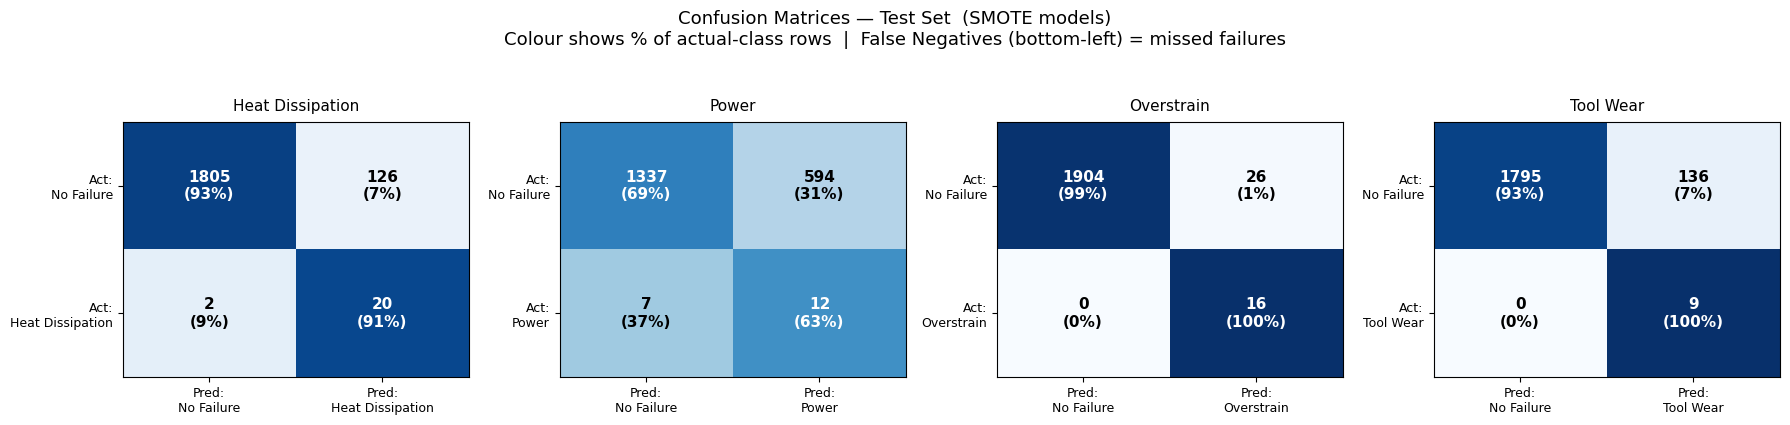

In [47]:
# ============================================================
# Plot 4: Confusion matrix heatmaps — SMOTE models
# Rows = Actual, Columns = Predicted
# Numbers show raw counts; colour shows proportion of row total
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(
    'Confusion Matrices — Test Set  (SMOTE models)\n'
    'Colour shows % of actual-class rows  |  '
    'False Negatives (bottom-left) = missed failures',
    fontsize=13, y=1.05
)

for ax, (ft, colour) in zip(axes, zip(FAILURE_TYPES, MODEL_COLOURS)):
    r  = results[(ft, 'smote')]
    cm = confusion_matrix(r['y_test'], r['y_pred'])

    # Normalise by row (true condition) so colours reflect recall
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1, aspect='auto')

    short = FAILURE_LABELS[ft]
    tick_labels = ['No Failure', short]
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pred:\nNo Failure', f'Pred:\n{short}'], fontsize=9)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Act:\nNo Failure', f'Act:\n{short}'], fontsize=9)
    ax.set_title(short, fontsize=11, pad=8)

    for i in range(2):
        for j in range(2):
            txt_col = 'white' if cm_norm[i, j] > 0.6 else 'black'
            ax.text(j, i,
                    f'{cm[i, j]}\n({cm_norm[i, j]*100:.0f}%)',
                    ha='center', va='center', fontsize=11,
                    color=txt_col, fontweight='bold')

plt.tight_layout()
plt.show()

### What the visualisations show

**Forest plot (Plot 1)**
- Heat Dissipation, Overstrain, and Tool Wear all have predictors that are clearly significant — bars well away from zero, tight confidence intervals. These are the models I can trust.
- Power Failure is a different story. The bars are short and most confidence intervals cross zero — the features I've engineered don't have a strong relationship with this failure type. I'll come back to this.
- The enormous bars for `Tool wear [min]` in Overstrain and Tool Wear are worth noting — this is a near-perfect separation effect. The direction is real, but the exact magnitude of the OR is inflated.

**Odds-ratio heatmap (Plot 2)**
- This is the clearest summary of what the GLMs found. The key patterns:
- `Tool wear [min]` is strongly red for Overstrain and Tool Wear → *replace tools on schedule*.
- `Power [W]` is red for Heat Dissipation and Overstrain → *avoid high-load operation*.
- `Temp diff [K]` is blue for Heat Dissipation — this is a protective feature. A larger gap between process and air temperature means the machine is dissipating heat effectively. A shrinking gap is the warning sign.
- Power Failure is pale across the board. The model cannot find a strong relationship with any of these three features.

**ROC curves (Plot 3)**
- Heat Dissipation, Overstrain, and Tool Wear all hit AUC ≈ 0.97–1.00 on the held-out test set. These features are genuinely useful predictors for these failure types.
- Power Failure AUC ≈ 0.63. Again, a good model for power failure was not learned.
- SMOTE and frequency weights produce almost identical ROC curves for every model, which is exactly what I was hoping to see — the relationships are robust.

**Confusion matrices (Plot 4)**
- The bottom-left cell is missed failures (false negatives) — in a maintenance context, this is the costly error.
- All three useful models catch the vast majority of actual failures, but at the cost of some false positives (operators sent to inspect machines that are fine). That trade-off is unavoidable at this level of class imbalance, and it's something I'll explore explicitly in the next section. It is worth noting the extremely low number of false positives for the overstrain model.

## Deriving Maintenance Rules from the Data

This is the part that actually answers my research question.

The GLMs have told me *which* features are statistically significant predictors of each failure type, and in which direction. Now I want to turn that into something an operator can actually use — a concrete threshold: *if tool wear exceeds X minutes, replace the tool head*.

### How the thresholds are derived

For each GLM-confirmed predictor, I bin the feature into 20 equal-width intervals and calculate the observed failure rate in each bin, along with a 95% Wilson confidence interval. The threshold is set at the **first bin where the failure rate crosses 1%** — the point where operating in that range starts to carry a meaningfully elevated risk relative to the dataset's overall background rates (0.45%–1.12% depending on failure type).

The 1% trigger is a policy choice, not a model output. I spent a lot of time thinking about model parameters for this project, but this is a business parameter. It depends on the cost of replacing machines, availability of workers, etc. 

### Why GLMs back up a threshold-based approach

A reasonable question is: why not just read the thresholds off the raw data and skip the GLMs entirely?

The GLMs confirm that the relationships are **statistically real and not just noise**. With failure classes as small as 0.45% of the data, it's easy to find patterns that are artefacts of the class imbalance. The GLMs — evaluated on a held-out test set, with two different imbalance strategies producing consistent results — give me confidence that the features I'm using to set thresholds are genuine predictors.

The thresholds themselves are set on the full dataset (all 10,000 rows), because a threshold is a policy decision, not a fitted parameter. More data gives a more stable estimate of where the failure rate actually crosses 1%. The statistical validity of the underlying relationships was already established on held-out data.

The 'Is it worth it?' charts on the right of each figure are in-sample — they show the observed recall/false-alarm trade-off at each threshold value in this dataset. They're useful for understanding the shape of the trade-off, but the specific percentages shouldn't be treated as held-out predictions of real-world performance.

### What's included (and what's not)

| Feature | Direction | Failure type(s) targeted |
|---|---|---|
| `Tool wear [min]` | Higher → more failures | Tool Wear Failure, Overstrain Failure |
| `Power [W]` | Higher → more failures | Heat Dissipation Failure, Overstrain Failure |
| `Temp diff [K]` | **Lower → more failures** | Heat Dissipation Failure |

Power Failure is not included. The GLM came back with AUC ≈ 0.63 — these three operational features simply don't predict power failures. A threshold derived from that data would be noise dressed up as a rule. I could build a more complex model to possibly better predict power failures, but then I'd lose the simplicity that allows me to set these clear thresholds.

> **Note:** This dataset is synthetic. The specific threshold values below are illustrative of the methodology. If I had real data, I'd be looking at things like machine cost, opportunity loss during downtime, worker availability, etc. to decide where these thresholds should go.

In [48]:
# ── Cell: failure_rate_curve() helper ───────────────────────────────────────

def wilson_ci(successes, n, z=1.96):
    """Wilson score confidence interval for a proportion.
    Returns (lower, upper) as fractions (not percentages).
    Handles n=0 gracefully."""
    if n == 0:
        return 0.0, 0.0
    p = successes / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    margin = (z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / denom
    return max(0.0, centre - margin), min(1.0, centre + margin)


def failure_rate_curve(feature, failure_types, n_bins=20, threshold_pct=1.0,
                       protective=False):
    """
    Bin `feature` into `n_bins` equal-width buckets and compute the observed
    failure rate for the given `failure_types` in each bucket.

    Parameters
    ----------
    feature       : str   — column name in df
    failure_types : list  — Failure Type labels to count as failures
    n_bins        : int   — number of equal-width bins
    threshold_pct : float — failure-rate % that defines the rule threshold
    protective    : bool  — if True, the feature is protective (lower = worse)
                           so the threshold is the LAST bin still below threshold_pct

    Returns
    -------
    curve_df  : DataFrame with columns bin_mid, n_total, n_fail, rate_pct,
                ci_lo_pct, ci_hi_pct
    threshold : float — feature value of the rule threshold
    """
    # Only rows that are either No Failure or one of the target failure types
    mask   = df['Failure Type'].isin(['No Failure'] + failure_types)
    d      = df[mask].copy()
    d['is_fail'] = d['Failure Type'].isin(failure_types).astype(int)

    feat_min, feat_max = d[feature].min(), d[feature].max()
    bins   = np.linspace(feat_min, feat_max, n_bins + 1)
    labels = 0.5 * (bins[:-1] + bins[1:])   # bin midpoints

    rows = []
    for lo, hi, mid in zip(bins[:-1], bins[1:], labels):
        subset  = d[(d[feature] >= lo) & (d[feature] < hi)]
        n_total = len(subset)
        n_fail  = subset['is_fail'].sum()
        rate    = (n_fail / n_total * 100) if n_total > 0 else 0.0
        lo_ci, hi_ci = wilson_ci(n_fail, n_total)
        rows.append(dict(bin_lo=lo, bin_hi=hi, bin_mid=mid,
                         n_total=n_total, n_fail=n_fail,
                         rate_pct=rate,
                         ci_lo_pct=lo_ci * 100,
                         ci_hi_pct=hi_ci * 100))

    curve_df = pd.DataFrame(rows)

    # Threshold: first bin (or first safe bin for protective features) crossing threshold_pct
    crosses = curve_df[curve_df['rate_pct'] >= threshold_pct]
    if protective:
        # protective: failures cluster at LOW values; scan left-to-right for the FIRST
        # bin where failure rate drops below threshold_pct (first 'safe' bin ~9 K)
        threshold = float(curve_df['bin_mid'].iloc[0])   # fallback: leftmost bin
        for _, row in curve_df.iterrows():
            if row['rate_pct'] < threshold_pct:
                threshold = float(row['bin_mid'])
                break
    else:
        threshold = float(crosses['bin_mid'].iloc[0]) if len(crosses) > 0 else float(curve_df['bin_mid'].iloc[-1])

    return curve_df, threshold


print('failure_rate_curve() helper ready.')

failure_rate_curve() helper ready.


Computing tool wear failure rate curves...
  Rule threshold (combined ≥1% failure rate): 183 min


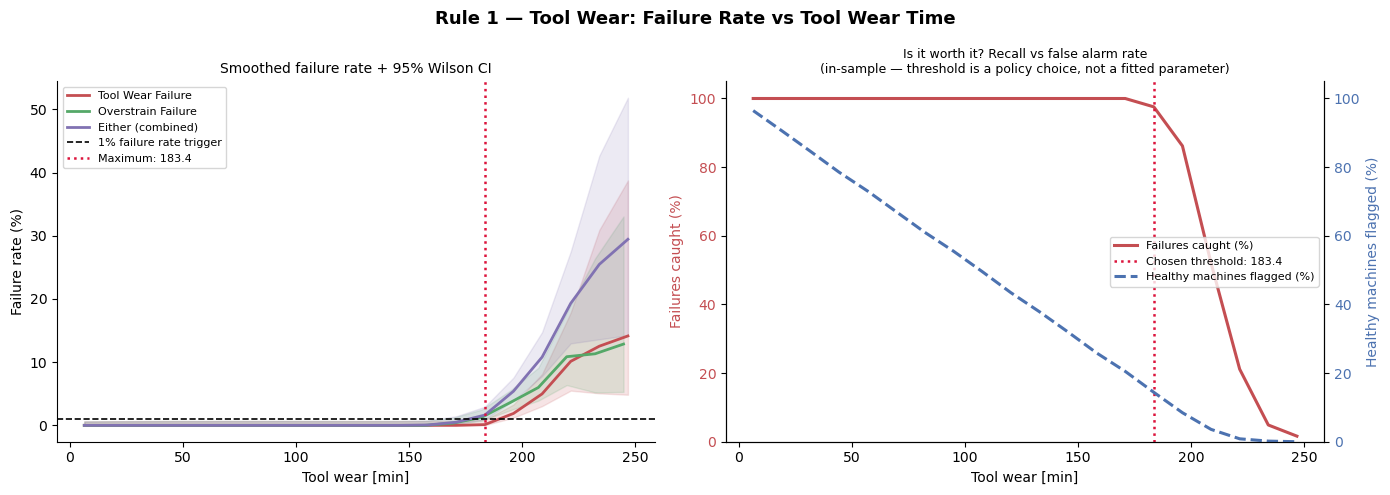


>>> Suggested Rule 1: Replace tool heads before 183 min of accumulated tool wear.

Computing power failure rate curves...
  Rule threshold (combined ≥1% failure rate): 6,668 W


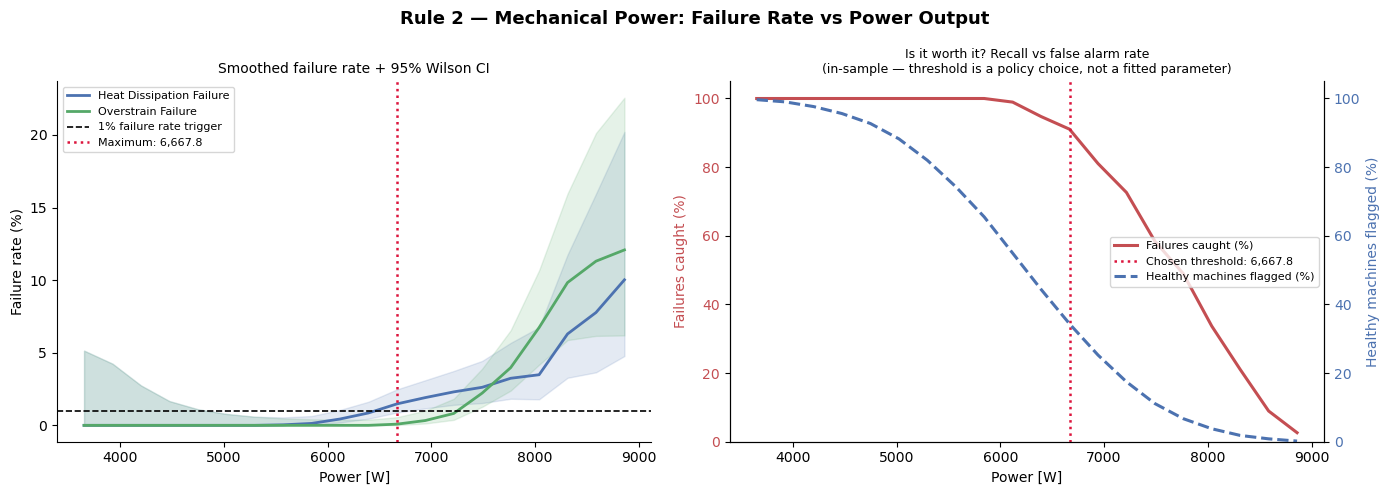


>>> Suggested Rule 2: Do not sustain mechanical power above 6,668 W.

Computing temp diff failure rate curves...
  Rule threshold (first safe bin, failure rate < 1%): 8.84 K


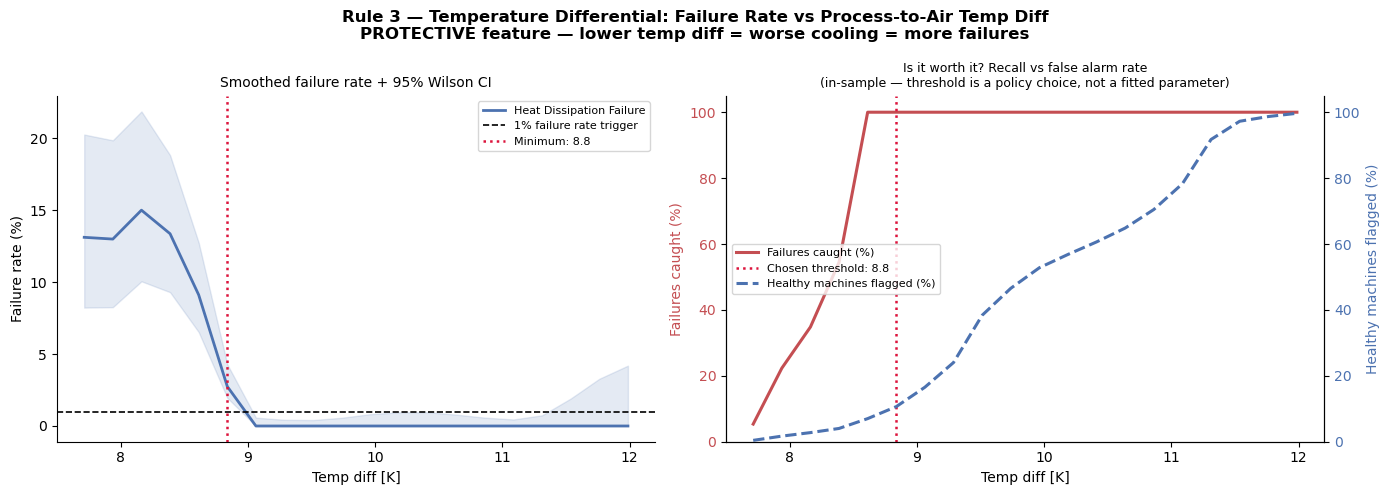


>>> Suggested Rule 3: Maintain process-to-air temperature differential above 8.8 K.
    A lower differential indicates inadequate heat dissipation.


In [51]:
# ── Cell: Rule plots ─────────────────────────────────────────────
#
# Layout per rule:
#   Left  — all three rules: smoothed line chart (3-bin rolling mean) + Wilson CI bands
#   Right — 'Is it worth it?' dual-axis sweep for every rule:
#             x-axis  : threshold value swept across all bin midpoints
#             red line: recall  = % of target failures caught at that threshold
#             blue line: false alarm rate = % of No-Failure rows flagged
#             vertical dotted line marks the chosen 1% rule threshold
#
# Stored thresholds are used in the 'failures prevented' cell that follows.

THRESHOLD_PCT = 1.0
N_BINS        = 20
SMOOTH_WIN    = 3

thresholds = {}   # populated below; used in later cells

TYPE_COLOURS = {
    'Tool Wear Failure'       : '#C44E52',
    'Overstrain Failure'      : '#55A868',
    'Tool Wear + Overstrain'  : '#8172B2',
    'Heat Dissipation Failure': '#4C72B0',
}


def _smooth(arr, win=SMOOTH_WIN):
    """Apply centred rolling mean to a numpy array."""
    return pd.Series(arr).rolling(win, center=True, min_periods=1).mean().values


def _decorate_left(ax, threshold, xlabel, protective=False):
    """Add 1% threshold line, rule vline, axis labels and spine cleanup."""
    direction = 'Minimum' if protective else 'Maximum'
    ax.axhline(THRESHOLD_PCT, color='black', lw=1.2, ls='--',
               label='1% failure rate trigger')
    ax.axvline(threshold, color='crimson', lw=1.8, ls=':',
               label=f'{direction}: {threshold:,.1f}')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Failure rate (%)', fontsize=10)
    ax.legend(fontsize=8, loc='upper right' if protective else 'upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def _worth_it_sweep(ax, feature, failure_types, rule_threshold,
                    xlabel, protective=False):
    """
    Right-panel 'Is it worth it?' chart.

    Sweeps the threshold across all bin midpoints from failure_rate_curve().
    At each candidate threshold:
      recall          = % of target failures caught (left y-axis, red)
      false_alarm_pct = % of all No-Failure rows flagged (right y-axis, blue)

    protective=False  → 'flag if feature >= threshold'  (Rules 1 & 2)
    protective=True   → 'flag if feature <  threshold'  (Rule 3)
    """
    curve_df, _ = failure_rate_curve(feature, failure_types, N_BINS, THRESHOLD_PCT,
                                     protective=protective)
    mids = curve_df['bin_mid'].values

    fail_rows  = df[df['Failure Type'].isin(failure_types)]
    nofail_rows = df[df['Failure Type'] == 'No Failure']
    n_fail    = len(fail_rows)
    n_nofail  = len(nofail_rows)

    recalls, false_alarms = [], []
    for t in mids:
        if protective:
            caught  = (fail_rows[feature]   < t).sum()
            flagged = (nofail_rows[feature] < t).sum()
        else:
            caught  = (fail_rows[feature]   >= t).sum()
            flagged = (nofail_rows[feature] >= t).sum()
        recalls.append(caught  / n_fail   * 100 if n_fail   > 0 else 0)
        false_alarms.append(flagged / n_nofail * 100 if n_nofail > 0 else 0)

    color_recall = '#C44E52'
    color_fa     = '#4C72B0'

    ax2 = ax.twinx()

    ax.plot(mids, recalls,     color=color_recall, lw=2.2, label='Failures caught (%)')
    ax2.plot(mids, false_alarms, color=color_fa,   lw=2.2, ls='--',
             label='Healthy machines flagged (%)')

    ax.axvline(rule_threshold, color='crimson', lw=1.8, ls=':',
               label=f'Chosen threshold: {rule_threshold:,.1f}')

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Failures caught (%)', color=color_recall, fontsize=10)
    ax2.set_ylabel('Healthy machines flagged (%)', color=color_fa, fontsize=10)
    ax.tick_params(axis='y', labelcolor=color_recall)
    ax2.tick_params(axis='y', labelcolor=color_fa)
    ax.set_ylim(0, 105)
    ax2.set_ylim(0, 105)

    # Combined legend from both axes
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8,
              loc='center right' if not protective else 'center left')
    ax.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)


# ═══════════════════════════════════════════════════════════════════════════
# RULE 1 — Tool wear [min]
# Three series: Tool Wear Failure, Overstrain Failure, combined
# ═══════════════════════════════════════════════════════════════════════════
print('Computing tool wear failure rate curves...')
tw_curve,  tw_thresh  = failure_rate_curve('Tool wear [min]', ['Tool Wear Failure'],  N_BINS, THRESHOLD_PCT)
os_curve,  os_thresh  = failure_rate_curve('Tool wear [min]', ['Overstrain Failure'], N_BINS, THRESHOLD_PCT)
com_curve, com_thresh = failure_rate_curve('Tool wear [min]',
                            ['Tool Wear Failure', 'Overstrain Failure'], N_BINS, THRESHOLD_PCT)

thresholds['tool_wear'] = com_thresh
print(f'  Rule threshold (combined ≥1% failure rate): {com_thresh:,.0f} min')

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Rule 1 — Tool Wear: Failure Rate vs Tool Wear Time',
    fontsize=13, fontweight='bold'
)

# Left: smoothed lines + CI bands for all three series
ax_left.set_title('Smoothed failure rate + 95% Wilson CI', fontsize=10)
for curve, colour, label in [
        (tw_curve,  TYPE_COLOURS['Tool Wear Failure'],     'Tool Wear Failure'),
        (os_curve,  TYPE_COLOURS['Overstrain Failure'],    'Overstrain Failure'),
        (com_curve, TYPE_COLOURS['Tool Wear + Overstrain'],'Either (combined)'),
]:
    mids  = curve['bin_mid'].values
    sm    = _smooth(curve['rate_pct'].values)
    lo_s  = _smooth(curve['ci_lo_pct'].values)
    hi_s  = _smooth(curve['ci_hi_pct'].values)
    ax_left.plot(mids, sm, color=colour, lw=2, label=label)
    ax_left.fill_between(mids, lo_s, hi_s, color=colour, alpha=0.15)

_decorate_left(ax_left, com_thresh, 'Tool wear [min]')

# Right: 'Is it worth it?' sweep for combined failure types
ax_right.set_title('Is it worth it? Recall vs false alarm rate\n(in-sample — threshold is a policy choice, not a fitted parameter)', fontsize=9)
_worth_it_sweep(ax_right, 'Tool wear [min]',
                ['Tool Wear Failure', 'Overstrain Failure'],
                com_thresh, 'Tool wear [min]')

plt.tight_layout()
plt.show()
print(f'\n>>> Suggested Rule 1: Replace tool heads before {com_thresh:,.0f} min of accumulated tool wear.')


# ═══════════════════════════════════════════════════════════════════════════
# RULE 2 — Power [W]
# Two series: Heat Dissipation, Overstrain; combined threshold used for rule
# ═══════════════════════════════════════════════════════════════════════════
print('\nComputing power failure rate curves...')
hd_curve,   hd_thresh   = failure_rate_curve('Power [W]', ['Heat Dissipation Failure'], N_BINS, THRESHOLD_PCT)
os2_curve,  os2_thresh  = failure_rate_curve('Power [W]', ['Overstrain Failure'],       N_BINS, THRESHOLD_PCT)
com2_curve, com2_thresh = failure_rate_curve('Power [W]',
                            ['Heat Dissipation Failure', 'Overstrain Failure'], N_BINS, THRESHOLD_PCT)

thresholds['power'] = com2_thresh
print(f'  Rule threshold (combined ≥1% failure rate): {com2_thresh:,.0f} W')

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Rule 2 — Mechanical Power: Failure Rate vs Power Output',
    fontsize=13, fontweight='bold'
)

# Left: smoothed lines + CI bands
ax_left.set_title('Smoothed failure rate + 95% Wilson CI', fontsize=10)
for curve, colour, label in [
        (hd_curve,   TYPE_COLOURS['Heat Dissipation Failure'], 'Heat Dissipation Failure'),
        (os2_curve,  TYPE_COLOURS['Overstrain Failure'],       'Overstrain Failure'),
]:
    mids  = curve['bin_mid'].values
    sm    = _smooth(curve['rate_pct'].values)
    lo_s  = _smooth(curve['ci_lo_pct'].values)
    hi_s  = _smooth(curve['ci_hi_pct'].values)
    ax_left.plot(mids, sm, color=colour, lw=2, label=label)
    ax_left.fill_between(mids, lo_s, hi_s, color=colour, alpha=0.15)

_decorate_left(ax_left, com2_thresh, 'Power [W]')

# Right: 'Is it worth it?' sweep
ax_right.set_title('Is it worth it? Recall vs false alarm rate\n(in-sample — threshold is a policy choice, not a fitted parameter)', fontsize=9)
_worth_it_sweep(ax_right, 'Power [W]',
                ['Heat Dissipation Failure', 'Overstrain Failure'],
                com2_thresh, 'Power [W]')

plt.tight_layout()
plt.show()
print(f'\n>>> Suggested Rule 2: Do not sustain mechanical power above {com2_thresh:,.0f} W.')


# ═══════════════════════════════════════════════════════════════════════════
# RULE 3 — Temp diff [K]  (protective: low temp diff = higher failure rate)
# One series: Heat Dissipation Failure
# ═══════════════════════════════════════════════════════════════════════════
print('\nComputing temp diff failure rate curves...')
td_curve, td_thresh = failure_rate_curve(
    'Temp diff [K]', ['Heat Dissipation Failure'], N_BINS, THRESHOLD_PCT, protective=True
)

thresholds['temp_diff'] = td_thresh
print(f'  Rule threshold (first safe bin, failure rate < 1%): {td_thresh:.2f} K')

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Rule 3 — Temperature Differential: Failure Rate vs Process-to-Air Temp Diff\n'
    'PROTECTIVE feature — lower temp diff = worse cooling = more failures',
    fontsize=12, fontweight='bold'
)

# Left: smoothed line + CI band (single series — matches Rule 1 & 2 layout)
ax_left.set_title('Smoothed failure rate + 95% Wilson CI', fontsize=10)
mids_td = td_curve['bin_mid'].values
sm_td   = _smooth(td_curve['rate_pct'].values)
lo_td   = _smooth(td_curve['ci_lo_pct'].values)
hi_td   = _smooth(td_curve['ci_hi_pct'].values)
ax_left.plot(mids_td, sm_td, color=TYPE_COLOURS['Heat Dissipation Failure'],
             lw=2, label='Heat Dissipation Failure')
ax_left.fill_between(mids_td, lo_td, hi_td,
                     color=TYPE_COLOURS['Heat Dissipation Failure'], alpha=0.15)
_decorate_left(ax_left, td_thresh, 'Temp diff [K]', protective=True)

# Right: 'Is it worth it?' sweep (protective direction)
ax_right.set_title('Is it worth it? Recall vs false alarm rate\n(in-sample — threshold is a policy choice, not a fitted parameter)', fontsize=9)
_worth_it_sweep(ax_right, 'Temp diff [K]',
                ['Heat Dissipation Failure'],
                td_thresh, 'Temp diff [K]', protective=True)

plt.tight_layout()
plt.show()
print(f'\n>>> Suggested Rule 3: Maintain process-to-air temperature differential above {td_thresh:.1f} K.')
print('    A lower differential indicates inadequate heat dissipation.')

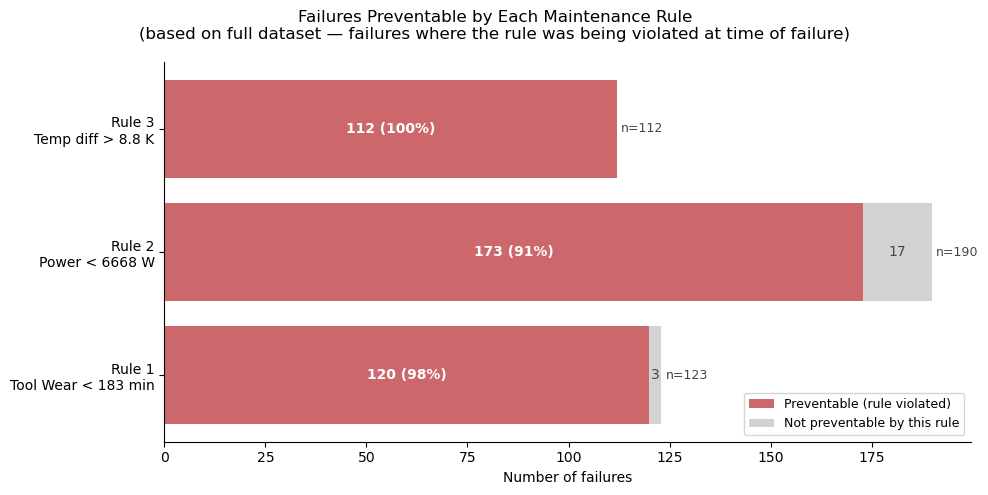


Preventability summary:
  Rule 1 Tool Wear < 183 min: 120 / 123 failures preventable (97.6%)
  Rule 2 Power < 6668 W: 173 / 190 failures preventable (91.1%)
  Rule 3 Temp diff > 8.8 K: 112 / 112 failures preventable (100.0%)


In [50]:
# ── Cell: Failures prevented simulation ──────────────────────────────────────
#
# For each rule, count how many actual failures in the full dataset occurred
# while the rule was being violated (i.e. preventable by the rule).
#
# A failure is 'preventable by Rule X' if, at the time of that failure,
# the relevant feature was on the wrong side of the threshold.

def count_preventable(feature, failure_types, threshold, protective=False):
    """
    Returns (n_preventable, n_total, pct) for the given rule.
    protective=True → failure occurs when feature < threshold (i.e. rule violated when below).
    protective=False → failure occurs when feature >= threshold (i.e. rule violated when above).
    """
    fail_rows = df[df['Failure Type'].isin(failure_types)]
    n_total   = len(fail_rows)
    if protective:
        # rule says 'keep above threshold'; violated when feature < threshold
        n_preventable = (fail_rows[feature] < threshold).sum()
    else:
        # rule says 'keep below threshold'; violated when feature >= threshold
        n_preventable = (fail_rows[feature] >= threshold).sum()
    pct = n_preventable / n_total * 100 if n_total > 0 else 0
    return int(n_preventable), int(n_total), pct


rule_results = {}

# Rule 1: tool wear
n_prev, n_tot, pct = count_preventable(
    'Tool wear [min]',
    ['Tool Wear Failure', 'Overstrain Failure'],
    thresholds['tool_wear']
)
rule_results['Rule 1\nTool Wear < {:.0f} min'.format(thresholds['tool_wear'])] = \
    dict(preventable=n_prev, not_preventable=n_tot - n_prev, total=n_tot, pct=pct,
         threshold=thresholds['tool_wear'], targets='Tool Wear + Overstrain')

# Rule 2: power
n_prev, n_tot, pct = count_preventable(
    'Power [W]',
    ['Heat Dissipation Failure', 'Overstrain Failure'],
    thresholds['power']
)
rule_results['Rule 2\nPower < {:.0f} W'.format(thresholds['power'])] = \
    dict(preventable=n_prev, not_preventable=n_tot - n_prev, total=n_tot, pct=pct,
         threshold=thresholds['power'], targets='Heat Dissipation + Overstrain')

# Rule 3: temp diff (protective)
n_prev, n_tot, pct = count_preventable(
    'Temp diff [K]',
    ['Heat Dissipation Failure'],
    thresholds['temp_diff'],
    protective=True
)
rule_results['Rule 3\nTemp diff > {:.1f} K'.format(thresholds['temp_diff'])] = \
    dict(preventable=n_prev, not_preventable=n_tot - n_prev, total=n_tot, pct=pct,
         threshold=thresholds['temp_diff'], targets='Heat Dissipation')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle(
    'Failures Preventable by Each Maintenance Rule\n'
    '(based on full dataset — failures where the rule was being violated at time of failure)',
    fontsize=12
)

rule_labels = list(rule_results.keys())
prev_counts = [v['preventable']     for v in rule_results.values()]
notprev_counts = [v['not_preventable'] for v in rule_results.values()]
pcts        = [v['pct']             for v in rule_results.values()]
y_pos       = np.arange(len(rule_labels))

bars_p = ax.barh(y_pos, prev_counts,    color='#C44E52', alpha=0.85, label='Preventable (rule violated)')
bars_n = ax.barh(y_pos, notprev_counts, left=prev_counts, color='#cccccc', alpha=0.85, label='Not preventable by this rule')

# Annotate each bar with count and percentage
for i, (p, np_, pct_) in enumerate(zip(prev_counts, notprev_counts, pcts)):
    total = p + np_
    ax.text(p / 2, i, f'{p} ({pct_:.0f}%)', ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')
    if np_ > 0:
        ax.text(p + np_ / 2, i, str(np_), ha='center', va='center',
                fontsize=10, color='#444444')
    # Total on the right
    ax.text(total + 1, i, f'n={total}', ha='left', va='center', fontsize=9, color='#444444')

ax.set_yticks(y_pos)
ax.set_yticklabels(rule_labels, fontsize=10)
ax.set_xlabel('Number of failures', fontsize=10)
ax.legend(fontsize=9, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Print summary
print('\nPreventability summary:')
for label, v in rule_results.items():
    short = label.replace('\n', ' ')
    print(f'  {short}: {v["preventable"]} / {v["total"]} failures preventable ({v["pct"]:.1f}%)')

## Maintenance Rules Summary

The three rules below are the direct answer to my research question. Threshold values are computed automatically from the dataset above — the exact numbers will depend on the data, but the methodology is repeatable.

| # | Rule | Threshold | Targets | Failures preventable |
|---|---|---|---|---|
| 1 | Replace tool heads | Tool wear < threshold min | Tool Wear + Overstrain Failure | See plot above |
| 2 | Limit mechanical power | Power < threshold W | Heat Dissipation + Overstrain Failure | See plot above |
| 3 | Maintain cooling performance | Temp diff > threshold K | Heat Dissipation Failure | See plot above |

### Reading these rules as an operator

**Rule 1 (Tool wear)** is the most clear-cut finding in the whole analysis. Tool wear is an almost perfect predictor of two separate failure types, and it's completely within operator control. Of the three rules, this one would have the biggest practical impact.

**Rule 2 (Power)** is about operating discipline. Machines running at sustained high mechanical load are more likely to overheat and overstrain. It should be noted that the threshold for preventing most power failures did affect many healthy machines. With real data, this might be a 'neccessary evil' sometimes you might need more powerful tools that break more often.

**Rule 3 (Temperature differential)** is a monitoring rule, not an action rule. A shrinking gap between process and air temperature is a warning sign that the cooling system isn't keeping up. If it drops below the threshold, that's the signal to investigate.

### Limitations

- **The rules aren't independent.** A machine simultaneously violating Rule 1 and Rule 2 faces compounded risk that neither rule individually captures. In practice, these should be treated as a combined risk picture, not three separate checklists.
- **Power failures aren't covered.** The GLM found no reliable relationship between these operational features and power failures (AUC ≈ 0.63). Any rule I derived from that data would be statistically unjustified. Power failure schedules should be driven by electrical engineering standards, not this analysis.
- **This is synthetic data.** The threshold numbers are illustrative. Before putting any of these into an operator manual, they'd need to be validated against real-world data and reviewed by someone with domain knowledge of the specific machines involved.

---

## Possible Extensions

There are a few natural directions to take this further:

**Random forests / decision trees** — a decision tree would be a particularly interesting follow-up to this analysis. Unlike the GLMs, a tree would automatically find interaction effects (e.g. high tool wear *and* high power simultaneously) and could produce a threshold structure that's still readable. A random forest would give better predictive accuracy at the cost of some interpretability, particularly as to how features combine to affect failure risk. 

**Adding tool quality (H/M/L)** — I excluded the `Type` feature after the EDA suggested it didn't make a meaningful difference to the failure relationships. It might be worth revisiting this with the GLMs directly — a model that includes `Type` as a categorical predictor would confirm whether lower-quality tools need to be replaced sooner, which would make Rule 1 more actionable.

**Interaction terms** — the GLMs I've fitted are additive (each predictor enters independently). An extended model with a `Tool wear × Power` interaction term would directly test whether high-wear, high-power conditions are disproportionately risky, rather than just assuming they compound.

---

## Conclusion

I set out to answer a specific question: **what maintenance rules and best practices can be learnt from this data and communicated to operators?** The answer, it turns out, is reasonably clear for three out of four failure types.

The GLMs confirmed that `Tool wear [min]`, `Power [W]`, and `Temp diff [K]` are statistically significant predictors of Heat Dissipation, Overstrain, and Tool Wear failures — with AUC scores between 0.97 and 1.00 on held-out data. Both imbalance strategies (SMOTE and frequency weights) agreed on the direction and significance of every coefficient, which gives me confidence the relationships are real.

From those confirmed relationships, three concrete threshold rules were derived. The most impactful is Rule 1 — a scheduled tool replacement programme — because tool wear predicts two failure types with near-perfect accuracy and is entirely within an operator's control. Rules 2 and 3 add complementary protections around mechanical load and cooling system monitoring.

Power failures remain unexplained by these features and warrant further investigation with different modelling techniques.

The broader point is that **maximising explainability and maximising predictive accuracy are different objectives**, and they sometimes pull in opposite directions. For my research question, GLMs gave me the statistical confidence in the effect of tool wear, power, and temp difference, needed to set simple maintenance thresholds.